# Compare COPER architectures on MIMIC-III mortality

Single codebase: `code/COPER` (newer; BMC 2024 / revised COPER stack).

Two **architecture** variants, toggled with `--second-node`:

- **1-NODE** (default): Neural ODE on the input sequence, then Perceiver (same as before).
- **2-NODE**: same as 1-NODE, plus a **second** Neural ODE applied on the Perceiver latent grid (`num_latents` tokens) before classification.

Same MIMIC-III mortality pickle and shared CLI hyperparameters for both runs.

`utils/run_exp.py` writes checkpoints with suffix `_N2` when `--second-node` is set (e.g. `..._S1_N2.ckpt`).

Training writes checkpoints, logs, and `Predictions_*.npz` under `code/COPER/results/` (via `--results-dir` in the notebook).

After training, checkpoints are exported to portable bundles (`.pt` + `.json`) via `utils/export_coper_checkpoint.py`.

Export names include **`_e{N}`** (e.g. `coper_1node_drop0.5_s1_e3.pt`) so bundles from different epoch counts do not overwrite each other. Keep **`NITERS`** in sync with `display_copers_embeddings.ipynb`.

In [1]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BENCH = Path('/home/charlesv/Desktop/StatisitcalGenetics/code/COPER').resolve()
if str(BENCH) not in sys.path:
    sys.path.insert(0, str(BENCH))

from utils.benchmark_utils import (
    patch_paths_json,
    restore_paths_json,
    run_one,
)

In [2]:
# ---- Paths and benchmark config ----
ROOT = Path('/home/charlesv/Desktop/StatisitcalGenetics')
REPO = ROOT / 'code' / 'COPER'
assert REPO.is_dir(), f'Missing repo: {REPO}'

# Training outputs (checkpoints, logs, Predictions_*.npz) go under --results-dir (default: results/ in this repo)
BENCH = ROOT / 'code' / 'COPER'
RESULTS_ROOT = BENCH / 'results'
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# (arch_id, human label, extra CLI tokens after SHARED_ARGS)
ARCHITECTURES = [
    ('coper_1node', '1-NODE (ODE → Perceiver)', []),
    ('coper_2node', '2-NODE (ODE → Perceiver → ODE on latents)', ['--second-node']),
]

FOLD = -1  # must match utils/run_exp default / your training setup (checkpoint name uses this)

MORTALITY_PICKLE = ROOT / 'MIMIC' / 'mimic3-benchmarks' / 'data' / 'mortality_for_coper.data'
assert MORTALITY_PICKLE.is_file(), f'Missing dataset file: {MORTALITY_PICKLE}'

# Smoke-test defaults. Increase for full benchmark.
SEEDS = [1]
DROPS = [0.50]  # drop ratio
NITERS = 3  # epochs (export bundles get suffix _e{NITERS})
BATCH_SIZE = 64
PATIENCE = 10

# Shared COPER hyperparameters (from run_irregular_mimic.sh)
SHARED_ARGS = [
    '--model-type', 'COPER',
    '--dataset', 'mimic',
    '--cont-in',
    '--self-per-cross-attn', '1',
    '--latent-heads', '2',
    '--cross-heads', '1',
    '--cross-dim-head', '128',
    '--latent-dim-head', '128',
    '--latent-dim', '64',
    '--units', '128',
    '--ode-dropout', '0.5',
    '--att-dropout', '0.5',
    '--ff-dropout', '0.5',
    '--num-latents', '48',
    '--batch-size', str(BATCH_SIZE),
    '--patience', str(PATIENCE),
    '--niters', str(NITERS),
    '--results-dir', str(RESULTS_ROOT.resolve()),
]

print('Repo:', REPO)
print('Results root:', RESULTS_ROOT)
print('Architectures:', [a[0] for a in ARCHITECTURES])
print('Dataset:', MORTALITY_PICKLE)

Repo: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER
Results root: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results
Architectures: ['coper_1node', 'coper_2node']
Dataset: /home/charlesv/Desktop/StatisitcalGenetics/MIMIC/mimic3-benchmarks/data/mortality_for_coper.data


In [3]:
# Utilities moved to utils.benchmark_utils

In [4]:
# ---- Run benchmark grid (1-NODE vs 2-NODE in one repo) ----
rows = []

backup = patch_paths_json(REPO, MORTALITY_PICKLE)
try:
    for arch_id, arch_label, extra_args in ARCHITECTURES:
        for seed in SEEDS:
            for drop in DROPS:
                print(f'Running {arch_id} [{arch_label}] | seed={seed} | drop={drop}')
                r = run_one(
                    arch_id=arch_id,
                    arch_label=arch_label,
                    extra_args=extra_args,
                    seed=seed,
                    drop=drop,
                    shared_args=SHARED_ARGS,
                    repo=REPO,
                    results_root=RESULTS_ROOT,
                    fold=FOLD,
                    python_executable=sys.executable,
                )
                rows.append(r)
                print(
                    f"  rc={r['return_code']} "
                    f"Test-OG AUROC={r['test_og_auroc']:.4f} "
                    f"Test-G AUROC={r['test_g_auroc']:.4f} "
                    f"ckpt_exists={r['ckpt_exists']}"
                )
                if r['return_code'] != 0:
                    print('  ---- error tail ----')
                    print(r['raw_tail'])
finally:
    restore_paths_json(REPO, backup)

results_df = pd.DataFrame(rows)

expected = {a[0] for a in ARCHITECTURES}
seen = set(results_df['arch_id'].unique())
assert not expected - seen, f'Missing architecture runs: {sorted(expected - seen)}'

results_df

Running coper_1node [1-NODE (ODE → Perceiver)] | seed=1 | drop=0.5
  rc=0 Test-OG AUROC=0.8088 Test-G AUROC=0.8049 ckpt_exists=True
Running coper_2node [2-NODE (ODE → Perceiver → ODE on latents)] | seed=1 | drop=0.5
  rc=0 Test-OG AUROC=0.7923 Test-G AUROC=0.8064 ckpt_exists=True


,arch_id,architecture,second_node,repo_dir,seed,drop,return_code,runtime_sec,ckpt_path,ckpt_exists,test_og_auroc,test_og_auprc,test_g_auroc,test_g_auprc,raw_tail
0,coper_1node,1-NODE (ODE → Perceiver),False,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.5,0,440.875837,/home/charlesv/Desktop/StatisitcalGenetics/cod...,True,0.8088,0.3813,0.8049,0.3743,"(11): Linear(in_features=128, ..."
1,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),True,/home/charlesv/Desktop/StatisitcalGenetics/cod...,1,0.5,0,878.294891,/home/charlesv/Desktop/StatisitcalGenetics/cod...,True,0.7923,0.3580,0.8064,0.3806,)\n (self_attns): ModuleList(\n (0...


In [5]:
# ---- Aggregate and compare ----
ok = results_df[results_df['return_code'] == 0].copy()
if ok.empty:
    raise RuntimeError('No successful runs. Inspect `results_df["raw_tail"]`.')

summary = (
    ok.groupby(['arch_id', 'second_node', 'drop'], as_index=False)[
        ['test_og_auroc', 'test_og_auprc', 'test_g_auroc', 'test_g_auprc', 'runtime_sec']
    ]
    .agg(['mean', 'std'])
)
summary

arch_id second_node drop test_og_auroc     test_og_auprc      \
                                         mean std          mean std   
0  coper_1node       False  0.5        0.8088 NaN        0.3813 NaN   
1  coper_2node        True  0.5        0.7923 NaN        0.3580 NaN   

  test_g_auroc     test_g_auprc     runtime_sec      
          mean std         mean std        mean std  
0       0.8049 NaN       0.3743 NaN  440.875837 NaN  
1       0.8064 NaN       0.3806 NaN  878.294891 NaN

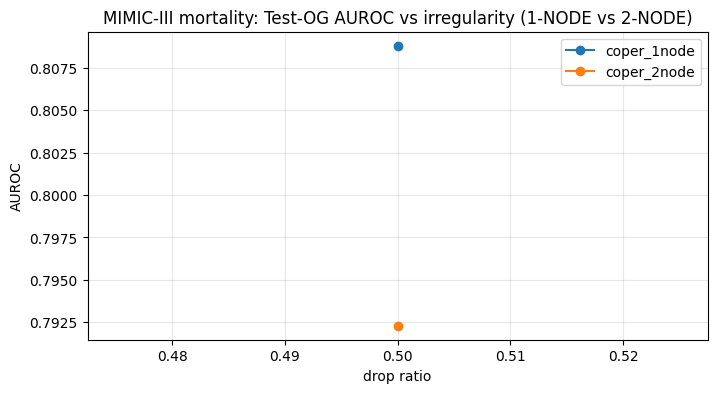

In [6]:
# ---- Plot Test-OG AUROC by drop ----
plot_df = ok.groupby(['arch_id', 'drop'], as_index=False)['test_og_auroc'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
for arch_id in plot_df['arch_id'].unique():
    chunk = plot_df[plot_df['arch_id'] == arch_id].sort_values('drop')
    ax.plot(chunk['drop'], chunk['test_og_auroc'], marker='o', label=arch_id)

ax.set_title('MIMIC-III mortality: Test-OG AUROC vs irregularity (1-NODE vs 2-NODE)')
ax.set_xlabel('drop ratio')
ax.set_ylabel('AUROC')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [7]:
# ---- Export checkpoints to portable bundles (.pt + .json) ----
EXPORT_SCRIPT = BENCH / 'utils' / 'export_coper_checkpoint.py'
ARTIFACTS_DIR = BENCH / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
assert EXPORT_SCRIPT.is_file(), f'Missing export script: {EXPORT_SCRIPT}'

ok_for_export = results_df[(results_df['return_code'] == 0) & (results_df['ckpt_exists'])].copy()
if ok_for_export.empty:
    raise RuntimeError('No successful runs with checkpoint files found for export.')

export_rows = []
for _, row in ok_for_export.iterrows():
    arch_id = row['arch_id']
    repo_dir = Path(row['repo_dir'])
    ckpt_path = Path(row['ckpt_path'])
    seed = int(row['seed'])
    drop = float(row['drop'])
    second_node = bool(row['second_node'])

    export_name = f'{arch_id}_drop{drop:g}_s{seed}_e{NITERS}'
    cmd = [
        sys.executable,
        str(EXPORT_SCRIPT),
        '--repo', str(repo_dir),
        '--ckpt', str(ckpt_path),
        '--out-dir', str(ARTIFACTS_DIR),
        '--name', export_name,
        '--drop', str(drop),
        '--random-seed', str(seed),
    ]
    if second_node:
        cmd.append('--second-node')

    print(f'Exporting {arch_id} -> {export_name}')
    proc = subprocess.run(cmd, text=True, capture_output=True, check=False)
    output = (proc.stdout or '') + '\n' + (proc.stderr or '')

    export_rows.append({
        'arch_id': arch_id,
        'architecture': row['architecture'],
        'second_node': second_node,
        'seed': seed,
        'drop': drop,
        'ckpt_path': str(ckpt_path),
        'bundle_name': export_name,
        'return_code': proc.returncode,
        'raw_tail': '\n'.join(output.splitlines()[-80:]),
    })

exports_df = pd.DataFrame(export_rows)
failed_exports = exports_df[exports_df['return_code'] != 0]
if not failed_exports.empty:
    display(exports_df)
    raise RuntimeError('Some checkpoint exports failed. Inspect `exports_df["raw_tail"]`.')

exports_df

Exporting coper_1node -> coper_1node_drop0.5_s1_e3
Exporting coper_2node -> coper_2node_drop0.5_s1_e3


,arch_id,architecture,second_node,seed,drop,ckpt_path,bundle_name,return_code,raw_tail
0,coper_1node,1-NODE (ODE → Perceiver),False,1,0.5,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_1node_drop0.5_s1_e3,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...
1,coper_2node,2-NODE (ODE → Perceiver → ODE on latents),True,1,0.5,/home/charlesv/Desktop/StatisitcalGenetics/cod...,coper_2node_drop0.5_s1_e3,0,Saved: /home/charlesv/Desktop/StatisitcalGenet...


In [8]:
# ---- Save results to disk ----
tables_dir = RESULTS_ROOT / 'tables'
tables_dir.mkdir(parents=True, exist_ok=True)
results_csv = tables_dir / 'mimic3_repo_comparison_raw.csv'
summary_csv = tables_dir / 'mimic3_repo_comparison_summary.csv'
exports_csv = tables_dir / 'mimic3_repo_export_summary.csv'

results_df.to_csv(results_csv, index=False)
summary.to_csv(summary_csv)
if 'exports_df' in globals():
    exports_df.to_csv(exports_csv, index=False)

print('Saved:', results_csv)
print('Saved:', summary_csv)
if exports_csv.exists():
    print('Saved:', exports_csv)

Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/tables/mimic3_repo_comparison_raw.csv
Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/tables/mimic3_repo_comparison_summary.csv
Saved: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/tables/mimic3_repo_export_summary.csv
